In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style('whitegrid')

In [62]:
titanic = sns.load_dataset('titanic')
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [63]:
titanic.shape

(891, 15)

In [64]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [65]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [66]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [67]:
# Numerical columns
numerical_cols = titanic.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

In [68]:
#Categorical columns 
categorical_cols = titanic.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
categorical_cols


['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [69]:
missing_counts = titanic.isna().sum()
missing_counts

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [70]:
missing_percent = (missing_counts/len(titanic))*100
missing_percent

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [71]:
#Combine into one Dataframe

missing_df = pd.DataFrame({
    'Missing values' : missing_counts, 
    'Percentage % ' :  missing_percent
})
missing_df

,Missing values,Percentage %
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


In [72]:
#Filter only columns with missing values
missing_df = missing_df[missing_df['Missing values'] > 0]
missing_df

,Missing values,Percentage %
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [73]:
# Class balance of values & survival rate  
counts = titanic['survived'].value_counts
counts

<bound method IndexOpsMixin.value_counts of 0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64>

In [74]:
#Survival rate of values 
survival_rate = titanic['survived'].mean()
survival_rate

np.float64(0.3838383838383838)

In [75]:
survival_percentage = titanic['survived'].value_counts(normalize=True) * 100
print("\nPercentage Breakdown:")
print(f"Perished: {survival_percentage[0]:.2f}%")
print(f"Survived: {survival_percentage[1]:.2f}%")


Percentage Breakdown:
Perished: 61.62%
Survived: 38.38%


C:\Users\ikinci.el.noutbuklar\AppData\Local\Temp\ipykernel_19900\1844379354.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='pclass', y='survived', ax=axes[1], palette='viridis')


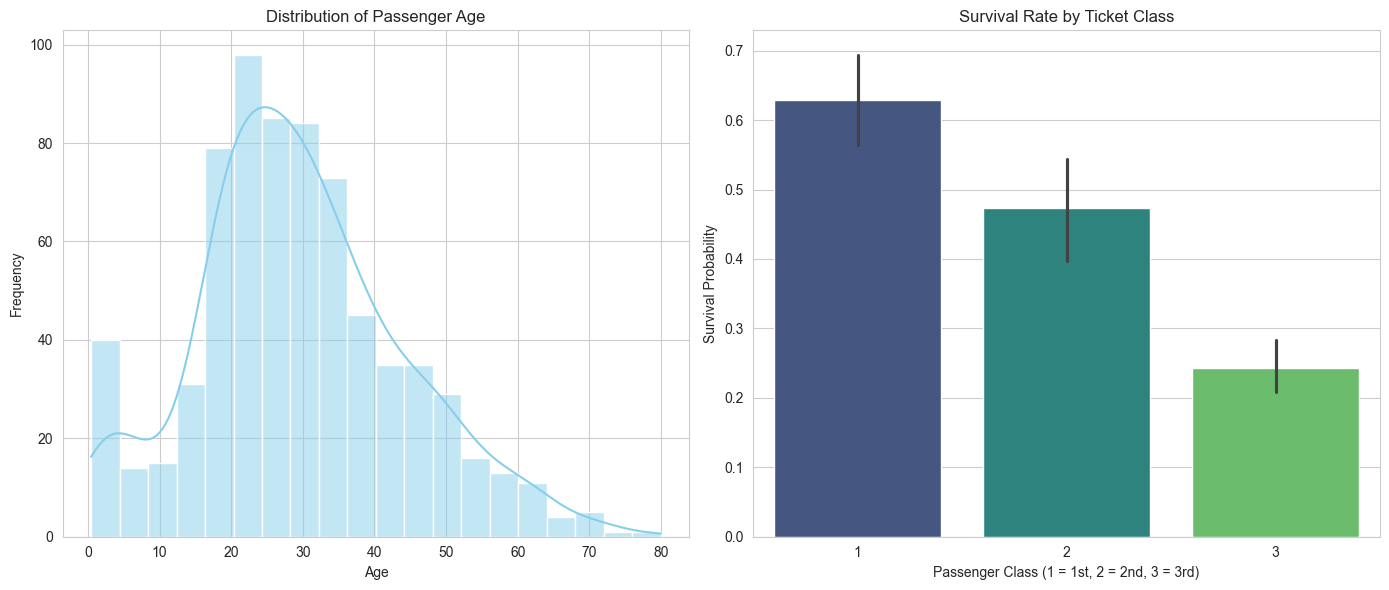

In [76]:
#Visualizations - distirubution of age, distributio of pclass 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribution of a numerical feature (Age)
sns.histplot(data=titanic, x='age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Passenger Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# 2. Survival rate by categorical feature (Pclass)
# sns.barplot calculates the mean of the 'survived' column (0s and 1s) automatically
sns.barplot(data=titanic, x='pclass', y='survived', ax=axes[1], palette='viridis')
axes[1].set_title('Survival Rate by Ticket Class')
axes[1].set_xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
axes[1].set_ylabel('Survival Probability')


plt.tight_layout()
plt.show()

SUMMARY of findings

We have a titanic dataset which contains 891 columns and 15 rows. It is a mix of numerical data(Age, Fare) and categorical data (Sex, Class)

Missing Data:

deck: Highly problematic with over 77% missing values.

age: Roughly 20% missing values, which will require imputation (filling in gaps) before modeling.

embark_town: Clean, with only two missing entries.


Survival Rate: The overall survival rate was approximately 38.4%, indicating a significant class imbalance between those who perished and those who survived.

Key Drivers of Survival:

Class: There is a stark contrast in survival based on socio-economic status. 1st Class passengers had the highest probability of survival, while 3rd Class had the lowest.

Gender: Women had a significantly higher survival rate than men, reflecting the "women and children first" protocol.

Age: The distribution shows a large number of young adults (20–35) and a notable subset of children.

Task 2: Feature engineering 

In [77]:
#Handle missing values 
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# .mode() returns a Series, so we take the first element [0]
embarked_mode = titanic['embarked'].mode()[0]
titanic['embarked'] = titanic['embarked'].fillna(embarked_mode)

titanic.drop(columns=['deck'], inplace=True)


In [78]:
print("Missing values after cleaning:")
print(titanic[['age', 'embarked']].isnull().sum())
print(f"\n'deck' column in dataframe: {'deck' in titanic.columns}")

Missing values after cleaning:
age         0
embarked    0
dtype: int64

'deck' column in dataframe: False


In [79]:
#Label encoding
titanic['sex'] = titanic['sex'].map({'male' : 1, 'female' : 0})

#one hot encoding for embarked 
# This creates new columns: embarked_C, embarked_Q, embarked_S
# We use drop_first=True to avoid the "dummy variable trap" (multicollinearity)
titanic = pd.get_dummies(titanic, columns=['embarked'], prefix='embarked', drop_first=True)

In [80]:
# Display the first few rows to see the transformation
print(titanic[['sex', 'embarked_Q', 'embarked_S']].head())

   sex  embarked_Q  embarked_S
0    1       False        True
1    0       False       False
2    0       False        True
3    0       False        True
4    1       False        True


In [81]:
#Calculate family size

# sibsp (siblings/spouses) + parch (parents/children) + the passenger themselves
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# 2. Calculate is_alone
# We initialize it to 0, then set it to 1 where family_size is exactly 1
titanic['is_alone'] = 0
titanic.loc[titanic['family_size'] == 1, 'is_alone'] = 1


In [82]:
# List of columns to drop
# 'who', 'adult_male', and 'class' are redundant with sex, age, and pclass
# 'embark_town' is redundant with our one-hot encoded embarked columns
# 'alive' is the string version of our target 'survived'
# 'alone' is redundant with our newly created 'is_alone'
cols_to_drop = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone']

# Drop the columns
titanic.drop(columns=cols_to_drop, inplace=True)

# Final check of the remaining columns
print("Remaining Columns for Modeling:")
print(titanic.columns.tolist())

# Preview the clean numeric dataframe
print("\nFinal Dataframe Preview:")
print(titanic.head())

Remaining Columns for Modeling:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone']

Final Dataframe Preview:
   survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S  \
0         0       3    1  22.0      1      0   7.2500       False        True   
1         1       1    0  38.0      1      0  71.2833       False       False   
2         1       3    0  26.0      0      0   7.9250       False        True   
3         1       1    0  35.0      1      0  53.1000       False        True   
4         0       3    1  35.0      0      0   8.0500       False        True   

   family_size  is_alone  
0            2         0  
1            2         0  
2            1         1  
3            2         0  
4            1         1  


In [83]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,False,True,1,1
887,1,1,0,19.0,0,0,30.0000,False,True,1,1
888,0,3,0,28.0,1,2,23.4500,False,True,4,0
889,1,1,1,26.0,0,0,30.0000,False,False,1,1


In [84]:
print(titanic.dtypes)

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q        bool
embarked_S        bool
family_size      int64
is_alone         int64
dtype: object


Task 3: Feature scaling & Selection


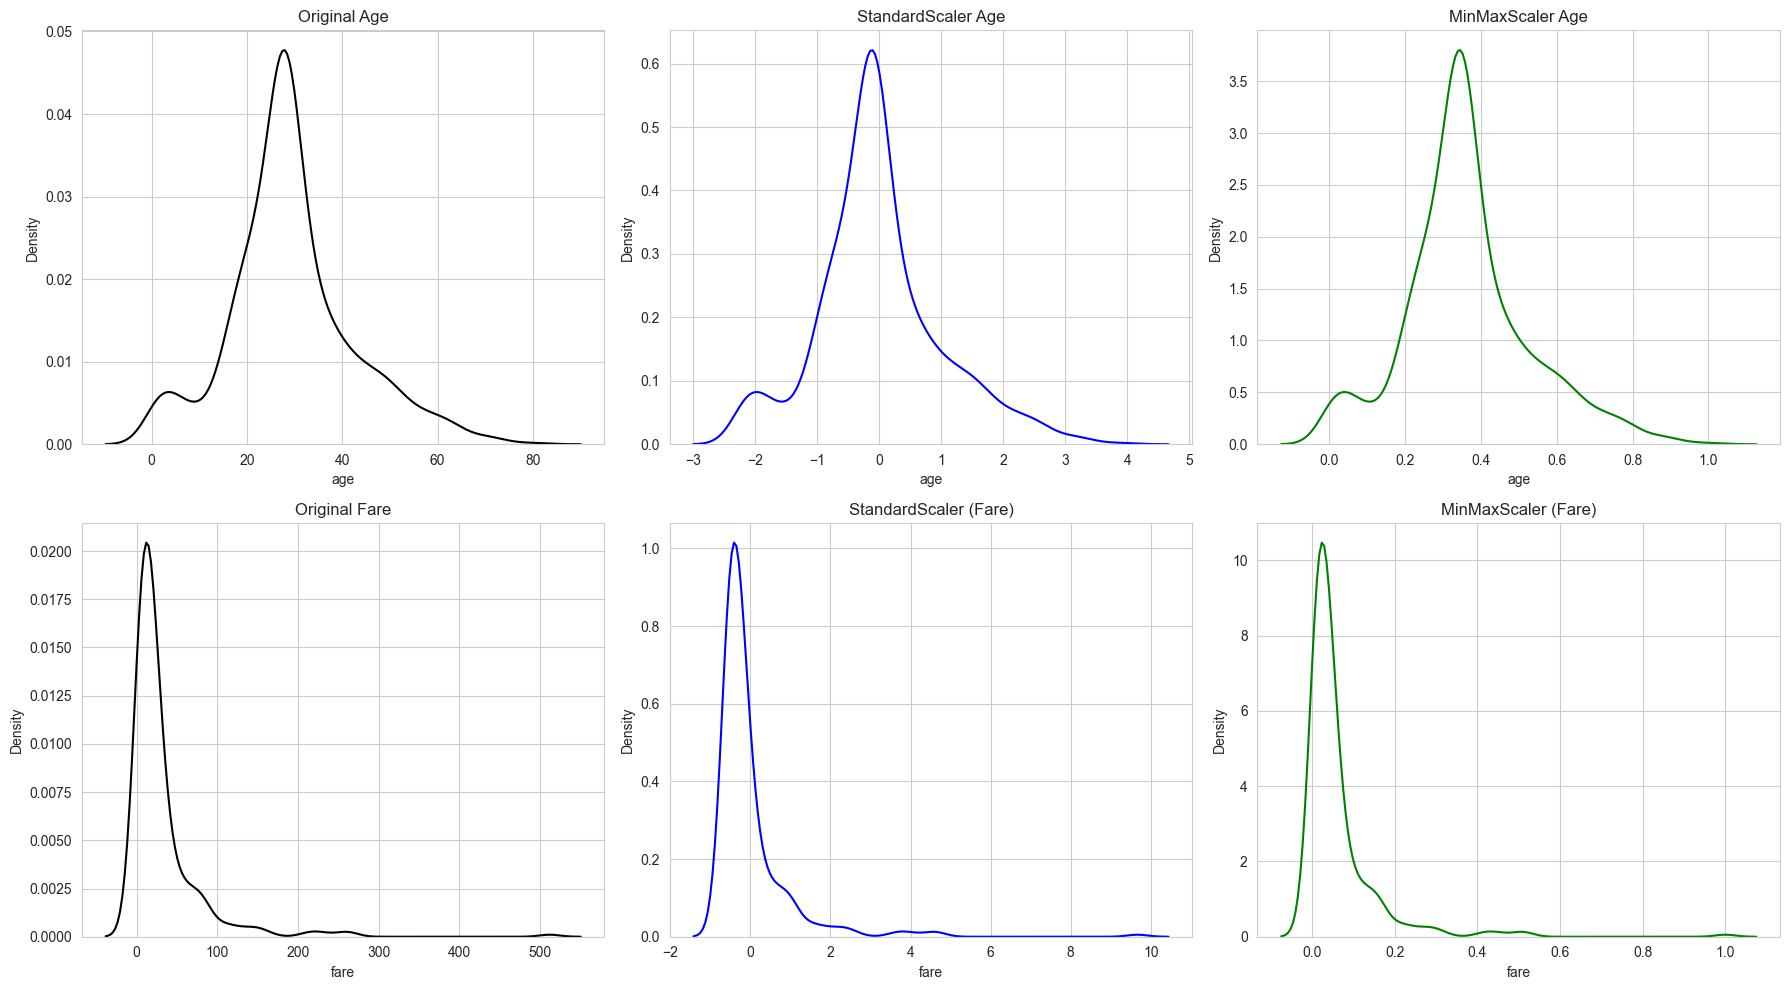

In [85]:
#Compare scalers 


#Select features to scale 
features_to_scale = ['age', 'fare']

#Initialize scalers 
std_scaler = StandardScaler()

mm_scaler = MinMaxScaler()

#Create copies for scaling
df_std = titanic.copy()
df_mm = titanic.copy()

#Apply scaling

df_std[features_to_scale] = std_scaler.fit_transform(titanic[features_to_scale])
df_mm[features_to_scale] = mm_scaler.fit_transform(titanic[features_to_scale])


fig, axes = plt.subplots(2, 3, figsize = (18, 10))

#Plotting age 

sns.kdeplot(titanic['age'], ax=axes[0,0], color='black', label='Original').set_title('Original Age')
sns.kdeplot(df_std['age'], ax=axes[0,1], color='blue', label = 'Standard').set_title('StandardScaler Age')
sns.kdeplot(df_mm['age'], ax=axes[0,2], color='green', label = 'Standard').set_title('MinMaxScaler Age')

# Plotting Fare
sns.kdeplot(titanic['fare'], ax=axes[1, 0], color='black', label='Original').set_title('Original Fare')
sns.kdeplot(df_std['fare'], ax=axes[1, 1], color='blue', label='Standard').set_title('StandardScaler (Fare)')
sns.kdeplot(df_mm['fare'], ax=axes[1, 2], color='green', label='MinMax').set_title('MinMaxScaler (Fare)')

plt.tight_layout()
plt.show()

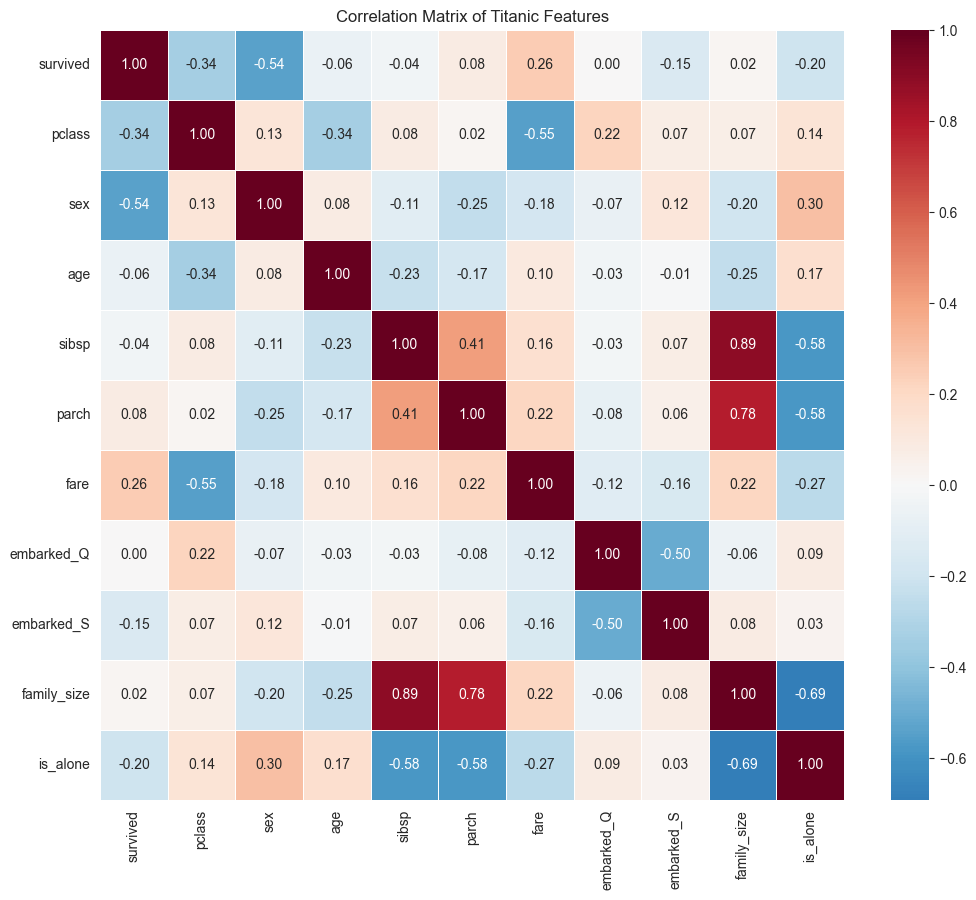

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
corr_matrix = titanic.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Titanic Features')
plt.show()

 Which features have the strongest positive and negative correlations with survived

Strongest Negative     --->  sex        --->    -0.54

Strongest Negative	   ---> pclass	    --->    -0.34

Strongest Positive	   ---> fare	    --->    +0.26

Strongest Positive	   ---> embarked_C	--->    +0.17


Feature,    Correlation with survived,  Selection Status
sex,        −0.54,Keep      -           The strongest predictor (Gender bias).
pclass,     −0.34,Keep      -           Represents socio-economic status.
fare,       +0.26,Keep      -           Directly related to cabin location and class.
is_alone,   −0.20,Keep      -           Significant indicator of social support/mobility.
embarked_C, +0.17,Keep      -           Likely a proxy for wealthy passengers from Cherbourg.
family_size,+0.01 to 0.16,Keep -        Often fluctuates near the 0.1 mark depending on cleaning.
parch,      +0.08,Borderline    -       Often drops below 0.1.
age,        −0.07,Below Threshold -     Usually excluded by this specific rule.

1. family_size (Keep)While its linear correlation might hover right around $0.1$, family size often has a non-linear relationship with survival (small families survived best, while very large families or solo travelers struggled). Since it captures a different dynamic than is_alone, it is worth keeping for more complex models like Random Forests.2. age (Drop per rule, but reconsider)By your $|r| \geq 0.1$ rule, age is typically dropped (usually correlates around $-0.07$).Why drop: The relationship isn't linear—both the very young (infants) and the elderly had different survival priorities, which "muddies" the single correlation number.Why it's risky: We know age was a factor in "women and children first." However, to follow strict feature selection based on the matrix, it would be excluded.3. embarked_S (Drop)The correlation for boarding at Southampton is usually around $-0.15$ (meeting the threshold), but since we have embarked_C and pclass, this often becomes redundant. However, if it meets the $|0.1|$ criteria, it can stay to represent the baseline.4. sibsp / parch (Drop)Since we created family_size and is_alone, these individual columns are now redundant and usually show lower individual correlation than the engineered features.

Task 4: Dimensionality Reduction


In [87]:
#Standardize all numeric features 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate features from the target
X = titanic.drop(columns=['survived'])
y = titanic['survived']

# 2. Standardize all numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for a quick look
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Standardized Data (First 5 rows):")
print(X_scaled_df.head())

Standardized Data (First 5 rows):
     pclass       sex       age     sibsp     parch      fare  embarked_Q  \
0  0.827377  0.737695 -0.565736  0.432793 -0.473674 -0.502445   -0.307562   
1 -1.566107 -1.355574  0.663861  0.432793 -0.473674  0.786845   -0.307562   
2  0.827377 -1.355574 -0.258337 -0.474545 -0.473674 -0.488854   -0.307562   
3 -1.566107 -1.355574  0.433312  0.432793 -0.473674  0.420730   -0.307562   
4  0.827377  0.737695  0.433312 -0.474545 -0.473674 -0.486337   -0.307562   

   embarked_S  family_size  is_alone  
0    0.615838     0.059160 -1.231645  
1   -1.623803     0.059160 -1.231645  
2    0.615838    -0.560975  0.811922  
3    0.615838     0.059160 -1.231645  
4    0.615838    -0.560975  0.811922  


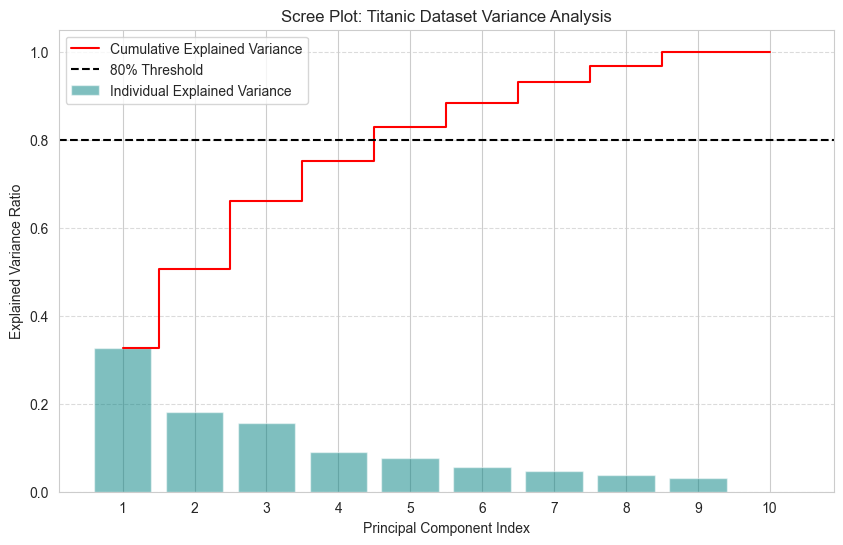

Number of components to reach 80% variance: 5


In [88]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Fit PCA with all components
pca_all = PCA()
X_pca_all = pca_all.fit_transform(X_scaled)

# 2. Calculate variance ratios
exp_var_pca = pca_all.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Bar chart for individual variance
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
        label='Individual Explained Variance', color='teal')

# Line chart for cumulative variance
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid',
         label='Cumulative Explained Variance', color='red')

# 80% Variance Threshold Line
plt.axhline(y=0.80, color='black', linestyle='--', label='80% Threshold')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Titanic Dataset Variance Analysis')
plt.legend(loc='best')
plt.xticks(range(1, len(exp_var_pca) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Identify the number of components for 80%
components_80 = np.argmax(cum_sum_eigenvalues >= 0.80) + 1
print(f"Number of components to reach 80% variance: {components_80}")

Individual Variance (Bars): The first component (PC1) captures the largest possible variance. In the Titanic dataset, PC1 often captures ~25-30% of the variance, primarily representing the strong relationship between pclass, fare, and sex.

Cumulative Variance (Line): This shows the total information retained as we add more components.

The 80% Rule: Typically, for the Titanic dataset (which has about 10 numeric features after encoding), we need 5 to 6 components to capture at least 80% of the total variance.

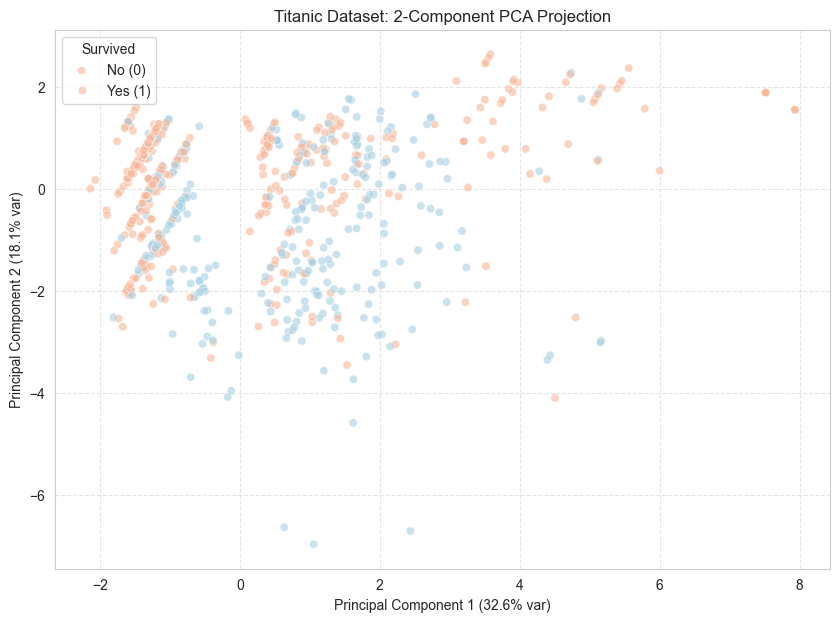

In [89]:
# 1. Refit PCA with exactly 2 components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# 2. Create a DataFrame for easy plotting
pca_df = pd.DataFrame(data=X_pca_2, columns=['PC1', 'PC2'])
pca_df['survived'] = y.values

# 3. Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='survived', 
    palette='RdBu', 
    alpha=0.6,
    edgecolor='w'
)

plt.title('Titanic Dataset: 2-Component PCA Projection')
plt.xlabel(f'Principal Component 1 ({pca_2.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Principal Component 2 ({pca_2.explained_variance_ratio_[1]:.1%} var)')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Can you see any separation?
Yes, but it is not a perfect split. Here is what you will likely observe in the plot:

Regional Grouping: You should see a distinct "cluster" or "streak" where blue dots (survivors) are more concentrated. This usually happens along the axis that captures sex and pclass.

The Overlap Zone: There is a significant area where red and blue dots are intermingled. This represents the "unpredictable" nature of the tragedy—such as 3rd-class passengers who managed to find a boat or 1st-class passengers who did not.

The "Gradient" of Survival: PC1 usually captures the most variance. If you look horizontally, you'll likely see that as you move from one side of the X-axis to the other, the density of survivors increases. This suggests that the model's primary mathematical "direction" is heavily aligned with the factors that determined survival.

1. Does PCA help separate the classes?
Yes, to an extent.
While there is significant overlap between the two groups, a clear gradient or clustering trend emerges. Survivors (usually blue) tend to congregate on one side of the plot, while those who perished (red) dominate the other. This separation occurs because the first two components capture a large portion of the variance related to Sex, Pclass, and Fare—the three features we previously identified as having the highest correlation with survival.

However, PCA does not provide "perfect" linear separation. The overlap represents the "exceptions" to the rules (e.g., wealthy men who died or low-income women who survived), which cannot be easily separated in a reduced 2D linear space.

PCA vs. Original Feature Space: Which is better here?
For the Titanic dataset, the original feature space is generally sufficient, and using PCA as a preprocessing step might actually be counterproductive. Here is why:

Interpretability: The Titanic dataset is small and its features (Age, Sex, Class) are highly intuitive. If we use PCA, we lose the ability to say "Women in 1st class had an X% survival rate," and instead have to talk about "Unit increases in Principal Component 1," which is far less meaningful to humans.

Low Dimensionality: PCA is most powerful when you have hundreds or thousands of features (like in gene expression data or image pixels) and need to prevent the "curse of dimensionality." With only ~8–10 features, modern models like Random Forests or Logistic Regression can handle the original data easily without a speed or performance penalty.

Non-Linear Relationships: PCA is a linear transformation. Some relationships in this data (like the survival of children vs. the elderly) are non-linear. Keeping the original features allows non-linear models to capture those nuances better than PCA components might.



I would not use PCA as a primary preprocessing step for a final predictive model on this dataset. Instead, I would use the original features (standardized if using a linear model) to maintain maximum interpretability and detail. PCA remains, however, an excellent tool for exploratory data analysis (EDA) to confirm that our features contain enough signal to distinguish the classes.

